In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import (
    KaplanMeierFitter,
    NelsonAalenFitter,
    ExponentialFitter,
    WeibullFitter,
    LogLogisticFitter,
    WeibullAFTFitter,
    CoxPHFitter,
)
from lifelines.statistics import logrank_test

from src.churn_classification.data_split import TEST_PATH, TRAIN_PATH

# Load data 

In [2]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
data = pd.concat([train_df, test_df], ignore_index=True)
data.shape

(7032, 21)

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,2876-GZYZC,Female,No,No,No,13,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.95,1215.65,No
1,6582-PLFUU,Male,No,Yes,Yes,51,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.55,1086.75,No
2,8073-IJDCM,Female,No,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.30,20.30,Yes
3,3001-CBHLQ,Male,Yes,Yes,No,32,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.90,3351.55,Yes
4,2018-PZKMU,Male,No,Yes,Yes,9,Yes,No,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,No,Electronic check,103.10,970.45,No


# Chuẩn bị duration và event

`tenure` là duration (số tháng khách đã ở lại). `Churn` là event: "Yes" nghĩa là
event đã xảy ra (khách rời đi tại thời điểm `tenure`), "No" nghĩa là censored
(khách vẫn đang ở lại, chưa biết khi nào sẽ rời đi).

In [4]:
duration_col = "tenure"
event_col = "event"

data[event_col] = (data["Churn"] == "Yes").astype(int)

data[[duration_col, event_col]].describe()

,tenure,event
count,7032.000000,7032.000000
mean,32.421786,0.265785
std,24.545260,0.441782
min,1.000000,0.000000
25%,9.000000,0.000000
50%,29.000000,0.000000
75%,55.000000,1.000000
max,72.000000,1.000000


# 1. Non-parametric

## 1.1. Kaplan-Meier

Ước lượng survival function S(t) = P(khách còn ở lại sau t tháng) trực tiếp
từ dữ liệu, không giả định phân phối nào cho thời gian sống.

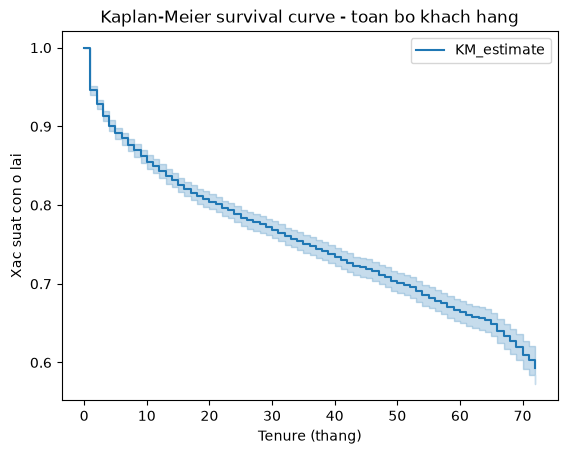

Median survival time: inf


In [5]:
kmf = KaplanMeierFitter()
kmf.fit(durations=data[duration_col], event_observed=data[event_col])

kmf.plot_survival_function()
plt.title("Kaplan-Meier survival curve - toan bo khach hang")
plt.xlabel("Tenure (thang)")
plt.ylabel("Xac suat con o lai")
plt.show()

print("Median survival time:", kmf.median_survival_time_)

## 1.2. Kaplan-Meier theo nhóm (Contract)

So sánh survival curve giữa các loại hợp đồng, và kiểm định log-rank xem
khác biệt giữa các nhóm có ý nghĩa thống kê không.

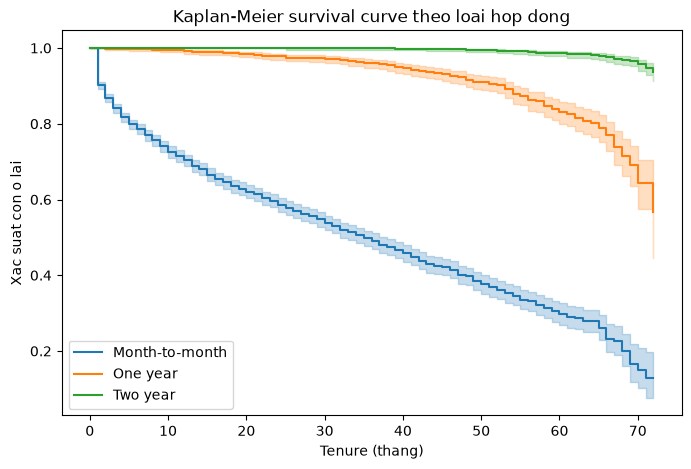

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

for contract_type, subset in data.groupby("Contract"):
    kmf.fit(subset[duration_col], subset[event_col], label=contract_type)
    kmf.plot_survival_function(ax=ax)

plt.title("Kaplan-Meier survival curve theo loai hop dong")
plt.xlabel("Tenure (thang)")
plt.ylabel("Xac suat con o lai")
plt.show()

In [7]:
month_to_month = data[data["Contract"] == "Month-to-month"]
one_year = data[data["Contract"] == "One year"]

results = logrank_test(
    month_to_month[duration_col],
    one_year[duration_col],
    event_observed_A=month_to_month[event_col],
    event_observed_B=one_year[event_col],
)
results.print_summary()

## 1.3. Nelson-Aalen

Ước lượng cumulative hazard H(t) — tổng "rủi ro" tích lũy đến thời điểm t.
Cùng loại non-parametric với Kaplan-Meier, chỉ khác ở đại lượng ước lượng.

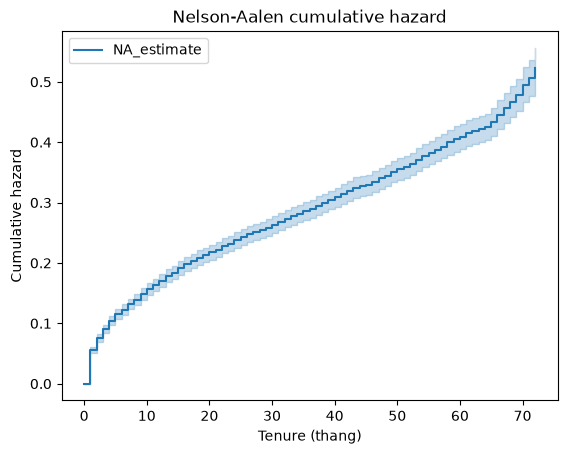

In [8]:
naf = NelsonAalenFitter()
naf.fit(data[duration_col], event_observed=data[event_col])

naf.plot_cumulative_hazard()
plt.title("Nelson-Aalen cumulative hazard")
plt.xlabel("Tenure (thang)")
plt.ylabel("Cumulative hazard")
plt.show()

# 2. Parametric

Giả định thời gian sống theo một phân phối xác suất cụ thể (Exponential,
Weibull, Log-Logistic). Nếu giả định đúng, model parametric cho ước lượng
mượt hơn và ngoại suy được ra ngoài khoảng dữ liệu quan sát, điều mà
Kaplan-Meier không làm được.

## 2.1. So sánh 3 phân phối (không covariates)

In [9]:
exp_model = ExponentialFitter().fit(data[duration_col], data[event_col], label="Exponential")
weibull_model = WeibullFitter().fit(data[duration_col], data[event_col], label="Weibull")
loglogistic_model = LogLogisticFitter().fit(data[duration_col], data[event_col], label="Log-Logistic")

for model in [exp_model, weibull_model, loglogistic_model]:
    print(f"{model._label}: AIC = {model.AIC_:.2f}")

Exponential: AIC = 21696.97
Weibull: AIC = 21156.57
Log-Logistic: AIC = 21139.91


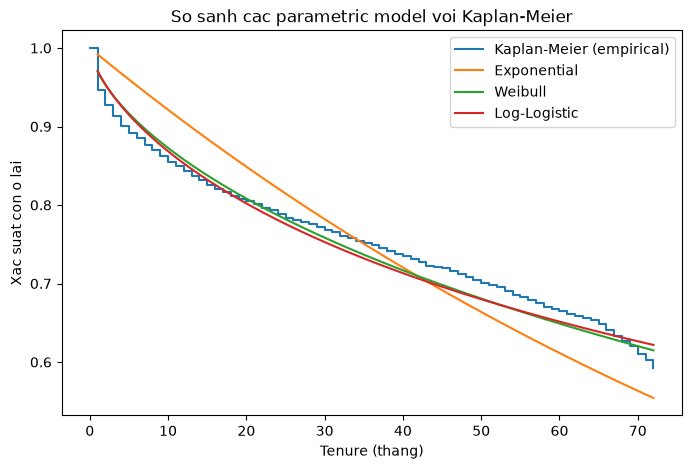

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

kmf.fit(data[duration_col], data[event_col], label="Kaplan-Meier (empirical)")
kmf.plot_survival_function(ax=ax, ci_show=False)
exp_model.plot_survival_function(ax=ax, ci_show=False)
weibull_model.plot_survival_function(ax=ax, ci_show=False)
loglogistic_model.plot_survival_function(ax=ax, ci_show=False)

plt.title("So sanh cac parametric model voi Kaplan-Meier")
plt.xlabel("Tenure (thang)")
plt.ylabel("Xac suat con o lai")
plt.show()

## 2.2. Weibull AFT (có covariates)

Bản parametric có regression, tương tự Cox PH nhưng giả định thời gian sống
theo phân phối Weibull. Cần one-hot encode các cột categorical trước.

`TotalCharges` bị loại vì gần như là tích của `tenure` và `MonthlyCharges`
(collinear với duration), `customerID` không có giá trị dự đoán.

Các cột add-on internet (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`,
`TechSupport`, `StreamingTV`, `StreamingMovies`) có mức "No internet service"
trùng lặp hoàn toàn với `InternetService == "No"` — gộp về "No" để tránh
multicollinearity giữa các cột này. Tương tự với "No phone service" ở
`MultipleLines` (trùng với `PhoneService == "No"`).

In [11]:
feature_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
    "MonthlyCharges",
]

internet_addon_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]

model_features = data[feature_cols].copy()
model_features[internet_addon_cols] = model_features[internet_addon_cols].replace(
    "No internet service", "No"
)
model_features["MultipleLines"] = model_features["MultipleLines"].replace(
    "No phone service", "No"
)

model_df = pd.get_dummies(model_features, drop_first=True)
model_df[duration_col] = data[duration_col]
model_df[event_col] = data[event_col]

model_df.shape

(7032, 23)

In [12]:
waft = WeibullAFTFitter()
waft.fit(model_df, duration_col=duration_col, event_col=event_col)
waft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 7032 total observations, 5163 right-censored observations>
             duration col = 'tenure'
                event col = 'event'
   number of observations = 7032
number of events observed = 1869
           log-likelihood = -8915.63
         time fit was run = 2026-07-22 08:44:36 UTC

---
                                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                              
lambda_ Contract_One year                      1.58      4.83      0.10            1.39            1.76                4.00                5.83
        Contract_Two year                      2.83     16.90      0.17            2.49            3.17               12.03               23.75
        Dependents_Yes                         0.10      1.11      0.07           -0.04            0.25                0.96                1.28
        DeviceProtection_Yes                   0.26      1.30      0.14           -0.00            0.53                1.00                1.70
        InternetService_Fiber optic           -0.71      0.49      0.62           -1.93            0.51                0.15                1.66
        InternetService_No                     1.50      4.47      0.63            0.26            2.74                1.29               15.49
        MonthlyCharges                         0.01      1.01      0.02           -0.04            0.06                0.96                1.06
        MultipleLines_Yes                      0.42      1.53      0.14            0.16            0.69                1.17                1.99
        OnlineBackup_Yes                       0.57      1.77      0.14            0.31            0.84                1.36                2.32
        OnlineSecurity_Yes                     0.63      1.87      0.14            0.35            0.91                1.41                2.48
        PaperlessBilling_Yes                  -0.20      0.82      0.06           -0.32           -0.08                0.72                0.92
        Partner_Yes                            0.51      1.66      0.06            0.39            0.62                1.48                1.86
        PaymentMethod_Credit card (automatic)  0.08      1.09      0.10           -0.11            0.27                0.90                1.32
        PaymentMethod_Electronic check        -0.63      0.53      0.08           -0.78           -0.48                0.46                0.62
        PaymentMethod_Mailed check            -0.63      0.53      0.10           -0.82           -0.45                0.44                0.64
        PhoneService_Yes                      -0.34      0.71      0.51           -1.34            0.66                0.26                1.94
        SeniorCitizen_Yes                      0.07      1.07      0.06           -0.05            0.19                0.95                1.21
        StreamingMovies_Yes                    0.01      1.01      0.25           -0.49            0.51                0.61                1.67
        StreamingTV_Yes                       -0.07      0.93      0.25           -0.57            0.43                0.56                1.53
        TechSupport_Yes                        0.41      1.51      0.14            0.13            0.69                1.14                2.00
        gender_Male                            0.07      1.08      0.05           -0.02            0.17                0.98                1.19
        Intercept                              3.20     24.57      0.63            1.97            4.43                7.16               84.26
rho_    Intercept                             -0.08      0.92      0.02           -0.12           -0.04                0.89                0.96

                                               cmp to     z      p

# 3. Semi-parametric: Cox PH

Không giả định phân phối cho survival function (giống non-parametric), chỉ
giả định các covariates tác động lên hazard theo tỷ lệ không đổi theo thời
gian (proportional hazards). Dùng lại `model_df` đã encode ở trên.

In [13]:
cph = CoxPHFitter()
cph.fit(model_df, duration_col=duration_col, event_col=event_col)
cph.print_summary()

print("Concordance index:", cph.concordance_index_)

<lifelines.CoxPHFitter: fitted with 7032 total observations, 5163 right-censored observations>
             duration col = 'tenure'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 7032
number of events observed = 1869
   partial log-likelihood = -13884.60
         time fit was run = 2026-07-22 08:44:37 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
MonthlyCharges                        -0.01      0.99      0.02           -0.05            0.04                0.95                1.04
gender_Male                           -0.09      0.92      0.05           -0.18            0.01                0.84                1.01
SeniorCitizen_Yes                     -0.07      0.93      0.06           -0.18            0.04                0.83                1.04
Partner_Yes                           -0.52      0.60      0.06           -0.63           -0.41                0.53                0.66
Dependents_Yes                        -0.05      0.95      0.07           -0.19            0.08                0.83                1.08
PhoneService_Yes                       0.25      1.29      0.47           -0.67            1.18                0.51                3.25
MultipleLines_Yes                     -0.42      0.66      0.13           -0.67           -0.17                0.51                0.84
InternetService_Fiber optic            0.59      1.80      0.58           -0.54            1.71                0.58                5.55
InternetService_No                    -1.30      0.27      0.59           -2.45           -0.15                0.09                0.86
OnlineSecurity_Yes                    -0.61      0.54      0.13           -0.87           -0.35                0.42                0.70
OnlineBackup_Yes                      -0.61      0.54      0.13           -0.86           -0.36                0.42                0.69
DeviceProtection_Yes                  -0.28      0.75      0.13           -0.53           -0.04                0.59                0.96
TechSupport_Yes                       -0.37      0.69      0.13           -0.63           -0.11                0.53                0.90
StreamingTV_Yes                        0.04      1.04      0.24           -0.42            0.50                0.66                1.66
StreamingMovies_Yes                   -0.05      0.95      0.24           -0.52            0.41                0.60                1.50
Contract_One year                     -1.62      0.20      0.09           -1.79           -1.44                0.17                0.24
Contract_Two year                     -3.23      0.04      0.16           -3.56           -2.91                0.03                0.05
PaperlessBilling_Yes                   0.18      1.20      0.06            0.07            0.29                1.07                1.34
PaymentMethod_Credit card (automatic) -0.08      0.92      0.09           -0.26            0.09                0.77                1.10
PaymentMethod_Electronic check         0.59      1.80      0.07            0.45            0.73                1.56                2.07
PaymentMethod_Mailed check             0.57      1.76      0.09            0.39            0.74                1.48                2.09

                                       cmp to      z      p  -log2(p)
covariate                                                            
MonthlyCharges                           0.00  -0.35   0.73      0.46
gender_Male                              0.00  -1.84   0.07      3.93
SeniorCitizen_Yes                        0.00  -1.26   0.21      2.27
Partner_Yes                              0.00  -9.40 <0.005     67.30
Dependents_Yes                           0.00  -0.78   0.43      1.20
PhoneService_Yes

Concordance index: 0.8663973792893547


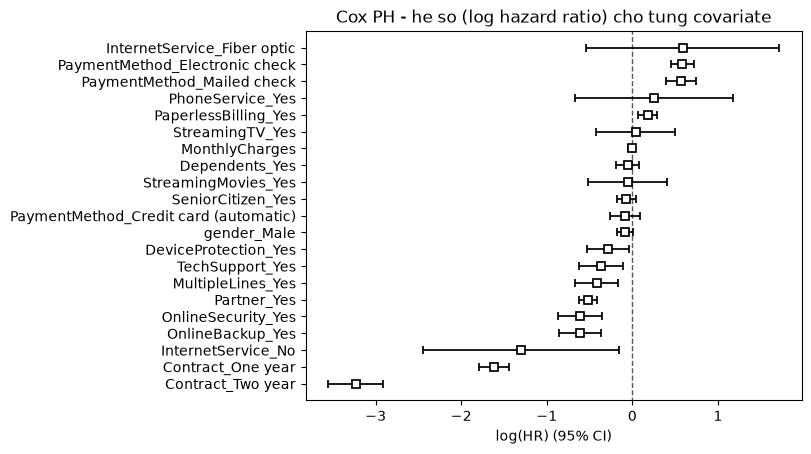

In [14]:
cph.plot()
plt.title("Cox PH - he so (log hazard ratio) cho tung covariate")
plt.show()

## 3.1. Kiểm tra proportional hazards assumption

Nếu một covariate vi phạm giả định (p-value nhỏ), hazard ratio của nó thực
ra thay đổi theo thời gian chứ không cố định — cần cân nhắc stratify hoặc
thêm time-interaction term cho covariate đó.

In [15]:
cph.check_assumptions(model_df, p_value_threshold=0.05, show_plots=False)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'Partner_Yes' failed the non-proportional test: p-value is 0.0412.

   Advice: with so few unique values (only 2), you can include `strata=['Partner_Yes', ...]` in the
call in `.fit`. See documentation in link [E] below.

2. Variable 'MultipleLines_Yes' failed the non-proportional test: p-value is 0.0047.

   Advice: with so few unique values (only 2), you can include `strata=['MultipleLines_Yes', ...]`
in the call in `.fit`. See documentation in link [E] below.

3. Variable 'OnlineSecurity_Yes' failed the non-proportional test: p-value is 0.0061.

   Advice: with so few unique values (only 2), you can include `strata=['OnlineSecurity_Yes', ...]`
in the call in `.fit`. See documentation in link [E] below.

4. Variable 'OnlineBackup_Yes' failed the non-proportional test: p-value is 0.0400.

   Advice: with so few unique values (only 2), you can include `strata=['OnlineBackup_Yes', ...]` in
the call in `.fit`. See documentation in link [E] below.

5. Variable 'TechSupport_Y

[]

## 3.2. Đọc kết quả kiểm định & quyết định xử lý

`check_assumptions` gắn cờ 10/22 covariate vi phạm proportional hazards ở ngưỡng p=0.05. Với ~7000 quan sát, một phần trong số đó là lệch nhỏ bị flag do cỡ mẫu lớn (ghi chú của chính lifelines) chứ không nhất thiết nghiêm trọng về mặt business. Vi phạm mạnh nhất là **`Contract_One year`** và **`Contract_Two year`** (p < 5e-05) — khớp với trực giác: khách hợp đồng dài hạn có hazard cực thấp và gần như không đổi, còn khách month-to-month có hazard giảm dần khi họ ở lại lâu hơn, nên tỷ lệ hazard giữa hai nhóm không phải hằng số theo thời gian.

**Thử stratify và một phát hiện ngược trực giác**: cách sách vở khuyên (`strata=['Contract_One year', 'Contract_Two year']`) loại bỏ đúng giả định bị vi phạm, nhưng cell dưới cho thấy concordance rơi từ **0.866 xuống 0.720**. Lý do: stratify không ước lượng hệ số cho biến đó nữa — toàn bộ sức mạnh phân biệt khổng lồ của `Contract` (yếu tố chi phối tốc độ churn, xác nhận bằng log-rank test ở mục 1.2) bị loại khỏi linear predictor, chỉ còn lại trong baseline hazard riêng của từng stratum.

**Quyết định**: giữ **Cox PH không stratify** làm model chính để diễn giải và dùng cho mục 5. Đánh đổi thực tế ở đây là giữa "tuân thủ chặt giả định thống kê" và "giữ được sức mạnh dự đoán từ biến quan trọng nhất" — với mục tiêu chính là diễn giải business (khách nào rời đi sớm) hơn là suy luận thống kê chặt chẽ về hazard ratio không đổi, đánh đổi 0.146 điểm concordance là không xứng đáng. Vi phạm PH của `Contract` được **ghi nhận là giới hạn đã biết** (hazard ratio của nó là trung bình theo thời gian, không phải hằng số) thay vì xử lý bằng stratification. Các vi phạm nhẹ hơn còn lại (`Partner`, `MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `TechSupport`, `StreamingTV`, `PaymentMethod`) cũng để nguyên vì cùng lý do, với mức độ vi phạm nhẹ hơn nhiều.

In [16]:
strata_cols = ["Contract_One year", "Contract_Two year"]
model_df_strat = model_df.copy()

cph_strat = CoxPHFitter()
cph_strat.fit(model_df_strat, duration_col=duration_col, event_col=event_col, strata=strata_cols)
cph_strat.print_summary()

print("Concordance index (unstratified):", cph.concordance_index_)
print("Concordance index (stratified by Contract):", cph_strat.concordance_index_)

<lifelines.CoxPHFitter: fitted with 7032 total observations, 5163 right-censored observations>
             duration col = 'tenure'
                event col = 'event'
                   strata = ['Contract_One year', 'Contract_Two year']
      baseline estimation = breslow
   number of observations = 7032
number of events observed = 1869
   partial log-likelihood = -13329.72
         time fit was run = 2026-07-22 08:44:37 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
MonthlyCharges                        -0.01      0.99      0.02           -0.05            0.04                0.95                1.04
gender_Male                           -0.07      0.93      0.05           -0.16            0.02                0.85                1.02
SeniorCitizen_Yes                     -0.06      0.94      0.06           -0.17            0.05                0.84                1.05
Partner_Yes                           -0.50      0.61      0.06           -0.60           -0.39                0.55                0.68
Dependents_Yes                        -0.06      0.94      0.07           -0.20            0.07                0.82                1.07
PhoneService_Yes                       0.27      1.31      0.47           -0.65            1.19                0.52                3.28
MultipleLines_Yes                     -0.41      0.67      0.13           -0.65           -0.16                0.52                0.85
InternetService_Fiber optic            0.61      1.84      0.57           -0.51            1.73                0.60                5.67
InternetService_No                    -1.27      0.28      0.58           -2.42           -0.13                0.09                0.88
OnlineSecurity_Yes                    -0.60      0.55      0.13           -0.86           -0.34                0.42                0.71
OnlineBackup_Yes                      -0.59      0.56      0.13           -0.83           -0.34                0.43                0.71
DeviceProtection_Yes                  -0.26      0.77      0.13           -0.50           -0.01                0.60                0.99
TechSupport_Yes                       -0.36      0.69      0.13           -0.62           -0.11                0.54                0.90
StreamingTV_Yes                        0.05      1.05      0.24           -0.41            0.51                0.67                1.67
StreamingMovies_Yes                   -0.02      0.98      0.23           -0.48            0.44                0.62                1.55
PaperlessBilling_Yes                   0.18      1.20      0.06            0.07            0.29                1.07                1.34
PaymentMethod_Credit card (automatic) -0.08      0.92      0.09           -0.26            0.09                0.77                1.10
PaymentMethod_Electronic check         0.58      1.78      0.07            0.44            0.72                1.55                2.05
PaymentMethod_Mailed check             0.58      1.79      0.09            0.41            0.76                1.51                2.13

                                       cmp to     z      p  -log2(p)
covariate                                                           
MonthlyCharges                           0.00 -0.41   0.68      0.55
gender_Male                              0.00 -1.58   0.11      3.13
SeniorCitizen_Yes                        0.00 -1.06   0.29      1.78
Partner_Yes                              0.00 -9.02 <0.005     62.18
Dependents_Yes                           0.00 -0.94   0.35      1.53
PhoneService_Yes                         0.00  0.57   0.57      0.82
MultipleLines_Yes                        0.00 -3.24 <0.005      9.69
InternetService_Fiber optic              0.00  1.07   0.29      1.81
InternetService_N

Concordance index (unstratified): 0.8663973792893547
Concordance index (stratified by Contract): 0.7204522556488653


## 4. So sánh model & lựa chọn

| Model | Loại | Metric | Giá trị |
|---|---|---|---|
| Exponential | Parametric, no covariates | AIC | 21696.97 |
| Weibull | Parametric, no covariates | AIC | 21156.57 |
| Log-Logistic | Parametric, no covariates | AIC | 21139.91 |
| Weibull AFT | Parametric, có covariates | log-likelihood | -8915.63 |
| **Cox PH** | Semi-parametric, có covariates | concordance | **0.8663** |
| Cox PH (stratified by Contract) | Semi-parametric, có covariates | concordance | 0.7205 |

**Model chính dùng để diễn giải business: Cox PH (không stratify).** Lý do: (1) concordance ~0.87 cao hơn nhiều so với các model non-parametric/parametric không covariate — covariates (đặc biệt Contract, InternetService) mang phần lớn thông tin về thời điểm churn; (2) so với Weibull AFT, Cox PH không áp đặt giả định về dạng phân phối cụ thể của thời gian sống; (3) hệ số Cox PH (hazard ratio) trực quan hơn cho business: "khách dùng Fiber optic có hazard gấp X lần khách DSL" dễ diễn giải hơn accelerated-failure-time factor của Weibull AFT; (4) bản stratified tuân thủ giả định PH chặt hơn nhưng đánh đổi mất 0.146 điểm concordance (xem mục 3.2) — không đáng cho mục tiêu diễn giải hiện tại.

Random Survival Forest (`scikit-survival`, đã có sẵn trong dependency group `notebooks`) là một hướng mở rộng hợp lý để so sánh non-linear vs. Cox — **cố ý để ngoài phạm vi** bản phân tích này để giữ gọn, không phải vì thiếu công cụ.

## 5. Kết luận & ý nghĩa business

**Model classification (`docs/docs.md`) trả lời "khách này có rời đi không", phân tích survival này trả lời thêm "nếu rời đi thì khi nào" — hai câu hỏi bổ sung cho nhau khi ưu tiên hành động giữ chân.**

Ba phát hiện chính, dùng được ngay cho việc ưu tiên retention:

1. **Loại hợp đồng là yếu tố chi phối tốc độ churn** (xác nhận bằng log-rank test ở mục 1.2, p rất nhỏ, và hazard ratio lớn nhất trong Cox PH). Khách month-to-month có hazard cao nhất và tập trung ở giai đoạn đầu vòng đời — đây là nhóm cần ưu tiên can thiệp sớm nhất, khớp với gợi ý từ notebook 05 (business value) rằng threshold phân loại nên nghiêng recall cho nhóm rủi ro cao.
2. **Hazard không cố định theo thời gian** (đây chính là lý do Contract vi phạm proportional hazards): với khách month-to-month, rủi ro rời đi cao nhất trong vài tháng đầu rồi giảm dần nếu họ ở lại — gợi ý một cửa sổ can thiệp cụ thể (vài tháng đầu) thay vì rải đều ưu đãi theo tenure.
3. **Model classification cho một xác suất tại một thời điểm snapshot; model survival cho thêm một đường cong theo thời gian** — hữu ích để ước tính "còn bao lâu nữa" cho từng khách đã bị model classification gắn cờ rủi ro cao, phục vụ việc xếp hạng ưu tiên trong hàng đợi can thiệp của team CS.

**Phạm vi cố tình bỏ qua** (nêu rõ để không nhầm là thiếu sót): phân tích này không được tích hợp vào FastAPI serving hay MLflow registry — nó là một góc nhìn bổ sung (exploratory extension) cho câu hỏi business "khi nào", không phải một model production song song với model classification. Tích hợp thật (serve survival curve theo từng khách) sẽ là bước mở rộng hợp lý tiếp theo nếu business cần, nhưng nằm ngoài phạm vi hiện tại.